<a href="https://colab.research.google.com/github/reyhan1997/museum_zoo_aqua/blob/main/museum_zoo_aqa_explore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
url = 'https://raw.githubusercontent.com/reyhan1997/museum_zoo_aqua/refs/heads/main/museums.csv'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(url)
df.head()

/tmp/ipykernel_1351/3173042584.py:1: DtypeWarning: Columns (9,14,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


,Museum ID,Museum Name,Legal Name,Alternate Name,Museum Type,Institution Name,Street Address (Administrative Location),City (Administrative Location),State (Administrative Location),Zip Code (Administrative Location),...,Latitude,Longitude,Locale Code (NCES),County Code (FIPS),State Code (FIPS),Region Code (AAM),Employer ID Number,Tax Period,Income,Revenue
0,8400200098,ALASKA AVIATION HERITAGE MUSEUM,ALASKA AVIATION HERITAGE MUSEUM,NaN,HISTORY MUSEUM,NaN,4721 AIRCRAFT DR,ANCHORAGE,AK,99502,...,61.17925,-149.97254,1.0,20.0,2.0,6,920071852,201312.0,602912.0,550236.0
1,8400200117,ALASKA BOTANICAL GARDEN,ALASKA BOTANICAL GARDEN INC,NaN,"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",NaN,4601 CAMPBELL AIRSTRIP RD,ANCHORAGE,AK,99507,...,61.16890,-149.76708,4.0,20.0,2.0,6,920115504,201312.0,1379576.0,1323742.0
2,8400200153,ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TEC...,ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TEC...,NaN,SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,NaN,9711 KENAI SPUR HWY,KENAI,AK,99611,...,60.56149,-151.21598,3.0,122.0,2.0,6,921761906,201312.0,740030.0,729080.0
3,8400200143,ALASKA EDUCATORS HISTORICAL SOCIETY,ALASKA EDUCATORS HISTORICAL SOCIETY,NaN,HISTORIC PRESERVATION,NaN,214 BIRCH STREET,KENAI,AK,99611,...,60.56280,-151.26597,3.0,122.0,2.0,6,920165178,201412.0,0.0,0.0
4,8400200027,ALASKA HERITAGE MUSEUM,ALASKA AVIATION HERITAGE MUSEUM,NaN,HISTORY MUSEUM,NaN,301 W NORTHERN LIGHTS BLVD,ANCHORAGE,AK,99503,...,61.17925,-149.97254,1.0,20.0,2.0,6,920071852,201312.0,602912.0,550236.0


In [4]:
df.tail()

,Museum ID,Museum Name,Legal Name,Alternate Name,Museum Type,Institution Name,Street Address (Administrative Location),City (Administrative Location),State (Administrative Location),Zip Code (Administrative Location),...,Latitude,Longitude,Locale Code (NCES),County Code (FIPS),State Code (FIPS),Region Code (AAM),Employer ID Number,Tax Period,Income,Revenue
33067,8405600184,WYOMING STATE HISTORICAL SOCIETY,WYOMING STATE HISTORICAL SOCIETY,NaN,HISTORIC PRESERVATION,NaN,PO BOX 73,SHERIDAN,WY,82801,...,44.82345,-106.87592,4.0,33.0,56.0,5,836007540.0,NaN,NaN,NaN
33068,8405600061,WYOMING STATE MUSEUM,WYOMING STATE MUSEUM VOLUNTEERS INC,NaN,GENERAL MUSEUM,NaN,2301 CENTRAL AVENUE,CHEYENNE,WY,82001,...,41.13941,-104.81813,1.0,21.0,56.0,5,237368629.0,201404.0,0.0,0.0
33069,8405600158,WYOMING TERRITORIAL PARK HISTORIC ASSOCIATION,WYOMING TERRITORIAL PARK HISTORIC ASSOCIATION INC,NaN,HISTORIC PRESERVATION,NaN,1273 N 15TH ST STE 121,LARAMIE,WY,82072,...,41.32276,-105.57686,3.0,1.0,56.0,5,830318392.0,201312.0,208508.0,83981.0
33070,8405600137,WYOMING TRANSPORTATION MUSEUM,WYOMING TRANSPORTATION MUSEUM CORP,NaN,HISTORY MUSEUM,NaN,PO BOX 704,CHEYENNE,WY,82003,...,41.13010,-104.81916,1.0,21.0,56.0,5,830295570.0,201309.0,0.0,0.0
33071,8405600199,YELLOWSTONE NATIONAL PARK,LITTLE PEOPLE LEARNING CENTER INC,NaN,HISTORIC PRESERVATION,NaN,NATIONAL PARK SERVICE,YELLOWSTONE NATIONAL PARK,WY,82190,...,44.91303,-110.41584,4.0,29.0,56.0,5,830249072.0,201312.0,127496.0,126762.0


In [5]:
df.shape

(33072, 25)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33072 entries, 0 to 33071
Data columns (total 25 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Museum ID                                 33072 non-null  int64  
 1   Museum Name                               33072 non-null  object 
 2   Legal Name                                33072 non-null  object 
 3   Alternate Name                            1927 non-null   object 
 4   Museum Type                               33072 non-null  object 
 5   Institution Name                          2749 non-null   object 
 6   Street Address (Administrative Location)  33062 non-null  object 
 7   City (Administrative Location)            33072 non-null  object 
 8   State (Administrative Location)           33072 non-null  object 
 9   Zip Code (Administrative Location)        33072 non-null  object 
 10  Street Address (Physical Location)

In [7]:
df.isnull().sum()

,0
Museum ID,0
Museum Name,0
Legal Name,0
Alternate Name,31145
Museum Type,0
Institution Name,30323
Street Address (Administrative Location),10
City (Administrative Location),0
State (Administrative Location),0
Zip Code (Administrative Location),0


In [8]:
df[['Income', 'Revenue']].describe()

,Income,Revenue
count,2.296100e+04,2.229000e+04
mean,1.069682e+08,2.097605e+07
std,2.509287e+09,2.485197e+08
min,-9.230000e+02,-2.127393e+06
25%,0.000000e+00,0.000000e+00
50%,8.781000e+03,3.307000e+03
75%,2.163770e+05,1.676960e+05
max,8.318144e+10,5.840349e+09


In [9]:
#Convert tax date from float64 into datetime data types
tax_date = pd.to_datetime(df['Tax Period'], format='%Y%m', errors = 'coerce')
tax_date

,Tax Period
0,2013-12-01
1,2013-12-01
2,2013-12-01
3,2014-12-01
4,2013-12-01
...,...
33067,NaT
33068,2014-04-01
33069,2013-12-01
33070,2013-09-01


In [10]:
tax_date.value_counts()

,count
Tax Period,
2013-12-01,10157
2014-12-01,4683
2014-06-01,2577
2013-06-01,1343
2014-09-01,616
...,...
2002-12-01,1
2007-12-01,1
2011-08-01,1


In [11]:
number_of_museum_type = df['Museum Type'].value_counts()
number_of_museum_type

,count
Museum Type,
HISTORIC PRESERVATION,14861
GENERAL MUSEUM,8699
ART MUSEUM,3241
HISTORY MUSEUM,2284
"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",1484
SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,1081
"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",564
CHILDREN'S MUSEUM,512
NATURAL HISTORY MUSEUM,346


In [12]:
revenue_museum = df.groupby('Museum Type')['Income'].sum()
revenue_museum

,Income
Museum Type,
"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",3.730393e+11
ART MUSEUM,6.143317e+11
CHILDREN'S MUSEUM,6.480484e+08
GENERAL MUSEUM,7.668677e+11
HISTORIC PRESERVATION,1.188386e+11
HISTORY MUSEUM,3.586002e+10
NATURAL HISTORY MUSEUM,1.439225e+11
SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,4.006399e+11
"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",1.948786e+09


In [13]:
df.groupby('Museum Type')[['Income', 'Revenue']].sum()

,Income,Revenue
Museum Type,,
"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",3.730393e+11,5.778638e+10
ART MUSEUM,6.143317e+11,1.858520e+11
CHILDREN'S MUSEUM,6.480484e+08,4.404932e+08
GENERAL MUSEUM,7.668677e+11,1.104060e+11
HISTORIC PRESERVATION,1.188386e+11,2.520482e+10
HISTORY MUSEUM,3.586002e+10,1.907755e+10
NATURAL HISTORY MUSEUM,1.439225e+11,2.009211e+10
SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,4.006399e+11,4.709544e+10
"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",1.948786e+09,1.601212e+09


In [14]:
income_museum = df.groupby('Museum Type')['Revenue'].sum()
income_museum

,Revenue
Museum Type,
"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",5.778638e+10
ART MUSEUM,1.858520e+11
CHILDREN'S MUSEUM,4.404932e+08
GENERAL MUSEUM,1.104060e+11
HISTORIC PRESERVATION,2.520482e+10
HISTORY MUSEUM,1.907755e+10
NATURAL HISTORY MUSEUM,2.009211e+10
SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,4.709544e+10
"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",1.601212e+09


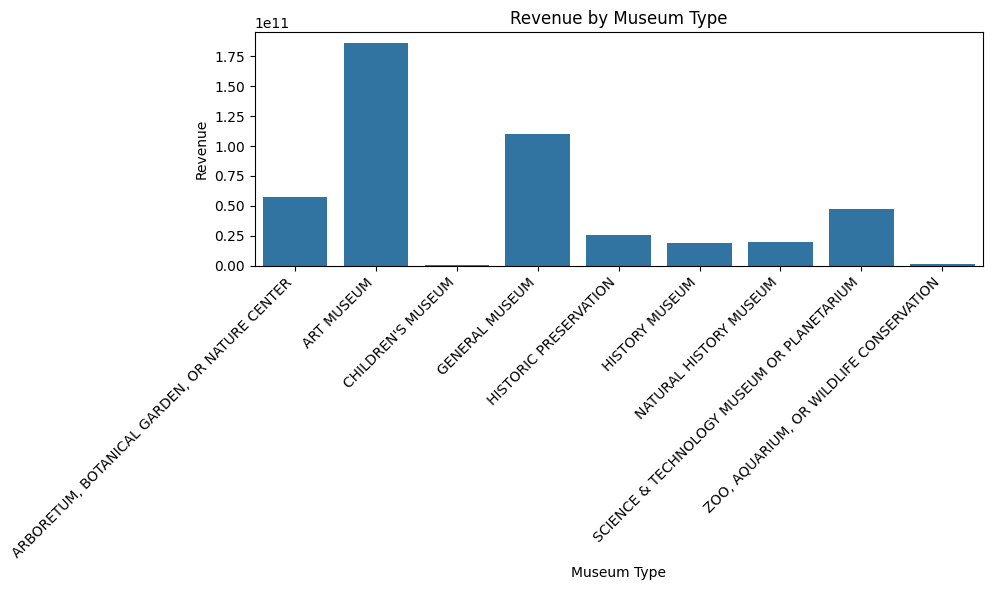

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(x=income_museum.index, y=income_museum.values)
plt.title('Revenue by Museum Type')
plt.ylabel('Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
import folium

# Filter for Natural History Museums
nat_hist_df = df[df['Museum Type'] == 'NATURAL HISTORY MUSEUM'].copy()

# Drop rows where Latitude or Longitude are missing
nat_hist_df.dropna(subset=['Latitude', 'Longitude'], inplace=True)

# Get the mean latitude and longitude to center the map
mean_latitude = nat_hist_df['Latitude'].mean()
mean_longitude = nat_hist_df['Longitude'].mean()

# Create a Folium map centered around the average coordinates
m = folium.Map(location=[mean_latitude, mean_longitude], zoom_start=4)

# Add markers for each natural history museum
for index, row in nat_hist_df.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=row['Museum Name'] # Show museum name on popup
    ).add_to(m)

# Display the map
m

In [17]:
#Confirm which museum type with null input in income and revenue
null_counts_by_museum_type = df.groupby('Museum Type')[['Income', 'Revenue']].apply(lambda x: x.isnull().sum())
display(null_counts_by_museum_type)

,Income,Revenue
Museum Type,,
"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",708,742
ART MUSEUM,1335,1397
CHILDREN'S MUSEUM,182,187
GENERAL MUSEUM,4373,4670
HISTORIC PRESERVATION,2317,2479
HISTORY MUSEUM,170,255
NATURAL HISTORY MUSEUM,102,111
SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,662,669
"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",262,272


In [18]:
#Confirm the cell with null input value
df_clean = df.isnull().dropna()
df_clean

,Museum ID,Museum Name,Legal Name,Alternate Name,Museum Type,Institution Name,Street Address (Administrative Location),City (Administrative Location),State (Administrative Location),Zip Code (Administrative Location),...,Latitude,Longitude,Locale Code (NCES),County Code (FIPS),State Code (FIPS),Region Code (AAM),Employer ID Number,Tax Period,Income,Revenue
0,False,False,False,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33067,False,False,False,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,True,True
33068,False,False,False,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
33069,False,False,False,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
33070,False,False,False,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [19]:
#Clear the null value

In [21]:
print(f"Original DataFrame shape: {df.shape}")

# Drop rows where 'Income' or 'Revenue' are null
df_cleaned = df.dropna(subset=['Income', 'Revenue'])

print(f"DataFrame shape after dropping nulls in 'Income' or 'Revenue': {df_cleaned.shape}")

# Update the main dataframe 'df' with the cleaned data
display(df_cleaned)

Original DataFrame shape: (22290, 25)
DataFrame shape after dropping nulls in 'Income' or 'Revenue': (22290, 25)


,Museum ID,Museum Name,Legal Name,Alternate Name,Museum Type,Institution Name,Street Address (Administrative Location),City (Administrative Location),State (Administrative Location),Zip Code (Administrative Location),...,Latitude,Longitude,Locale Code (NCES),County Code (FIPS),State Code (FIPS),Region Code (AAM),Employer ID Number,Tax Period,Income,Revenue
0,8400200098,ALASKA AVIATION HERITAGE MUSEUM,ALASKA AVIATION HERITAGE MUSEUM,NaN,HISTORY MUSEUM,NaN,4721 AIRCRAFT DR,ANCHORAGE,AK,99502,...,61.17925,-149.97254,1.0,20.0,2.0,6,920071852,201312.0,602912.0,550236.0
1,8400200117,ALASKA BOTANICAL GARDEN,ALASKA BOTANICAL GARDEN INC,NaN,"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",NaN,4601 CAMPBELL AIRSTRIP RD,ANCHORAGE,AK,99507,...,61.16890,-149.76708,4.0,20.0,2.0,6,920115504,201312.0,1379576.0,1323742.0
2,8400200153,ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TEC...,ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TEC...,NaN,SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,NaN,9711 KENAI SPUR HWY,KENAI,AK,99611,...,60.56149,-151.21598,3.0,122.0,2.0,6,921761906,201312.0,740030.0,729080.0
3,8400200143,ALASKA EDUCATORS HISTORICAL SOCIETY,ALASKA EDUCATORS HISTORICAL SOCIETY,NaN,HISTORIC PRESERVATION,NaN,214 BIRCH STREET,KENAI,AK,99611,...,60.56280,-151.26597,3.0,122.0,2.0,6,920165178,201412.0,0.0,0.0
4,8400200027,ALASKA HERITAGE MUSEUM,ALASKA AVIATION HERITAGE MUSEUM,NaN,HISTORY MUSEUM,NaN,301 W NORTHERN LIGHTS BLVD,ANCHORAGE,AK,99503,...,61.17925,-149.97254,1.0,20.0,2.0,6,920071852,201312.0,602912.0,550236.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33063,8405600122,WYOMING SECONDARY ART EDUCATORS ASSOCIATION,WYOMING SECONDARY ART EDUCATORS ASSOCIATION INC,NaN,ART MUSEUM,NaN,601 GRACE AVE,WORLAND,WY,82401,...,44.01382,-107.96000,3.0,43.0,56.0,5,830265250.0,201312.0,43695.0,43695.0
33068,8405600061,WYOMING STATE MUSEUM,WYOMING STATE MUSEUM VOLUNTEERS INC,NaN,GENERAL MUSEUM,NaN,2301 CENTRAL AVENUE,CHEYENNE,WY,82001,...,41.13941,-104.81813,1.0,21.0,56.0,5,237368629.0,201404.0,0.0,0.0
33069,8405600158,WYOMING TERRITORIAL PARK HISTORIC ASSOCIATION,WYOMING TERRITORIAL PARK HISTORIC ASSOCIATION INC,NaN,HISTORIC PRESERVATION,NaN,1273 N 15TH ST STE 121,LARAMIE,WY,82072,...,41.32276,-105.57686,3.0,1.0,56.0,5,830318392.0,201312.0,208508.0,83981.0
33070,8405600137,WYOMING TRANSPORTATION MUSEUM,WYOMING TRANSPORTATION MUSEUM CORP,NaN,HISTORY MUSEUM,NaN,PO BOX 704,CHEYENNE,WY,82003,...,41.13010,-104.81916,1.0,21.0,56.0,5,830295570.0,201309.0,0.0,0.0
